# Semana 14: Storytelling aplicado al proyecto de créditos hipotecarios
# Ticket de Salida 

En este notebook se trabaja con los datos reales del proyecto Data Traders, enfocado en créditos hipotecarios. El objetivo es transformar el análisis técnico realizado en semanas anteriores en indicadores útiles para la toma de decisiones.

El análisis considera variables como banco, CAE, monto del crédito, región, tipo de interés, pie, dormitorios y tendencia del CAE. A partir de estos datos se construyen KPIs para tres niveles organizacionales: estratégico, táctico y operacional.


In [6]:
from pymongo import MongoClient
from getpass import getpass
from urllib.parse import quote_plus
import certifi

usuario = "joaquinserey_db_user"

# Escribe la contraseña cuando Jupyter la pida
CONTRASENA = quote_plus(getpass("Ingresa la contraseña de MongoDB Atlas: "))

uri = (
    f"mongodb+srv://{usuario}:{CONTRASENA}"
    f"@datatreaders.xake49k.mongodb.net/"
    f"HipotecarioChile?retryWrites=true&w=majority&appName=DataTraders"
)

client = MongoClient(
    uri,
    tlsCAFile=certifi.where(),
    serverSelectionTimeoutMS=5000
)

client.admin.command("ping")

print("Conexión exitosa con MongoDB Atlas")

Ingresa la contraseña de MongoDB Atlas:  ········


Conexión exitosa con MongoDB Atlas


In [7]:
db = client["HipotecarioChile"]

print("Colecciones disponibles:")
print(db.list_collection_names())

Colecciones disponibles:
['clustered_data', 'processed_data', 'datos_hipotecarios']


In [10]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F

try:
    spark.stop()
except:
    pass

spark = SparkSession.builder \
    .appName("Semana14_Storytelling_Creditos_Hipotecarios") \
    .config("spark.mongodb.read.connection.uri", uri) \
    .getOrCreate()

df_historico = spark.read.format("mongodb") \
    .option("database", "HipotecarioChile") \
    .option("collection", "processed_data") \
    .load()

print("Datos cargados correctamente")
print("Cantidad de registros:", df_historico.count())

df_historico.printSchema()
df_historico.show(5)

Datos cargados correctamente
Cantidad de registros: 2469
root
 |-- _id: string (nullable = true)
 |-- banco: string (nullable = true)
 |-- cae: double (nullable = true)
 |-- cae_origen: string (nullable = true)
 |-- cuota_estimada: double (nullable = true)
 |-- date: string (nullable = true)
 |-- desviacion_vs_banco: double (nullable = true)
 |-- dormitorios: integer (nullable = true)
 |-- escenario_financiamiento: string (nullable = true)
 |-- estacionamiento: boolean (nullable = true)
 |-- extractor: string (nullable = true)
 |-- fuente: string (nullable = true)
 |-- id_registro: string (nullable = true)
 |-- integrante: string (nullable = true)
 |-- monto: double (nullable = true)
 |-- monto_financiado_uf: double (nullable = true)
 |-- monto_pie_uf: double (nullable = true)
 |-- periodo: string (nullable = true)
 |-- pie: double (nullable = true)
 |-- plazo_anios: double (nullable = true)
 |-- region: string (nullable = true)
 |-- sube_cae: double (nullable = true)
 |-- tendencia: s

In [12]:
print("Columnas disponibles:")
print(df_historico.columns)

Columnas disponibles:
['_id', 'banco', 'cae', 'cae_origen', 'cuota_estimada', 'date', 'desviacion_vs_banco', 'dormitorios', 'escenario_financiamiento', 'estacionamiento', 'extractor', 'fuente', 'id_registro', 'integrante', 'monto', 'monto_financiado_uf', 'monto_pie_uf', 'periodo', 'pie', 'plazo_anios', 'region', 'sube_cae', 'tendencia', 'tipo_inmueble', 'tipo_interes', 'tipo_registro', 'titulo_proyecto', 'ubicacion_detalle', 'url_fuente', 'url_pagina_scrapeada', 'variacion_mensual']


In [13]:
import pyspark.sql.functions as F

columnas_numericas = [
    "cae",
    "monto",
    "cuota_estimada",
    "desviacion_vs_banco",
    "dormitorios",
    "monto_financiado_uf",
    "monto_pie_uf",
    "pie",
    "plazo_anios",
    "sube_cae",
    "variacion_mensual"
]

for columna in columnas_numericas:
    if columna in df_historico.columns:
        df_historico = df_historico.withColumn(columna, F.col(columna).cast("double"))

print("Datos preparados correctamente")
df_historico.printSchema()

Datos preparados correctamente
root
 |-- _id: string (nullable = true)
 |-- banco: string (nullable = true)
 |-- cae: double (nullable = true)
 |-- cae_origen: string (nullable = true)
 |-- cuota_estimada: double (nullable = true)
 |-- date: string (nullable = true)
 |-- desviacion_vs_banco: double (nullable = true)
 |-- dormitorios: double (nullable = true)
 |-- escenario_financiamiento: string (nullable = true)
 |-- estacionamiento: boolean (nullable = true)
 |-- extractor: string (nullable = true)
 |-- fuente: string (nullable = true)
 |-- id_registro: string (nullable = true)
 |-- integrante: string (nullable = true)
 |-- monto: double (nullable = true)
 |-- monto_financiado_uf: double (nullable = true)
 |-- monto_pie_uf: double (nullable = true)
 |-- periodo: string (nullable = true)
 |-- pie: double (nullable = true)
 |-- plazo_anios: double (nullable = true)
 |-- region: string (nullable = true)
 |-- sube_cae: double (nullable = true)
 |-- tendencia: string (nullable = true)
 |-

## Matriz de indicadores por nivel organizacional

| Nivel organizacional | KPI                                          | Variables usadas                | Frecuencia           | Objetivo                                                                        |
| -------------------- | -------------------------------------------- | ------------------------------- | -------------------- | ------------------------------------------------------------------------------- |
| Estratégico          | CAE promedio por banco                       | banco, cae, monto               | Mensual / Trimestral | Comparar el costo promedio de los créditos hipotecarios entre bancos.           |
| Táctico              | Tendencia del CAE por región                 | region, tendencia, cae          | Mensual              | Identificar regiones donde el CAE tiende a subir, bajar o mantenerse estable.   |
| Operacional          | Créditos con CAE sobre el promedio del banco | banco, cae, desviacion_vs_banco | Por carga de datos   | Detectar créditos que están por encima del comportamiento promedio de su banco. |


In [14]:
kpi_estrategico = df_historico.groupBy("banco").agg(
    F.round(F.avg("cae"), 2).alias("CAE_promedio"),
    F.round(F.avg("monto"), 2).alias("Monto_promedio"),
    F.count("*").alias("Cantidad_creditos")
).orderBy(F.desc("CAE_promedio"))

print("KPI Estratégico: CAE promedio por banco")
kpi_estrategico.show(truncate=False)

KPI Estratégico: CAE promedio por banco
+--------------+------------+--------------+-----------------+
|banco         |CAE_promedio|Monto_promedio|Cantidad_creditos|
+--------------+------------+--------------+-----------------+
|Santander     |5.01        |2181.14       |599              |
|BancoEstado   |4.76        |2180.0        |600              |
|BCI           |4.29        |3022.0        |184              |
|referencia_cmf|4.25        |7822.13       |1086             |
+--------------+------------+--------------+-----------------+



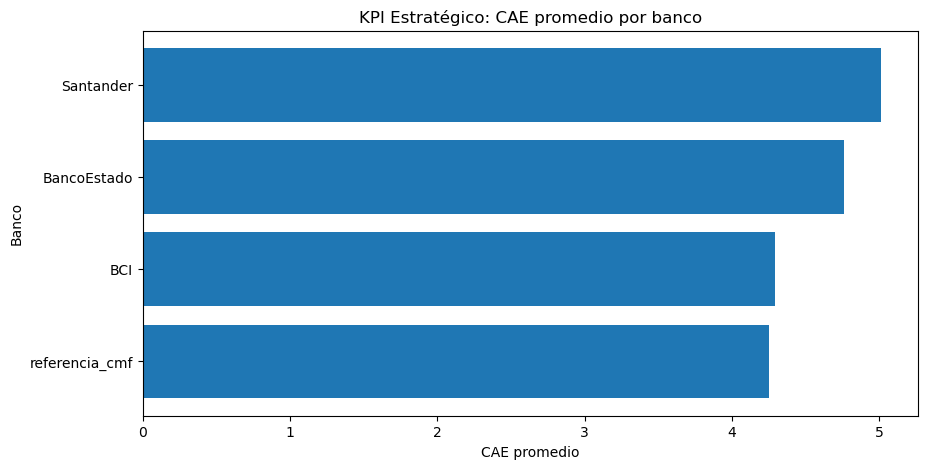

In [18]:
import matplotlib.pyplot as plt
# Convertir KPI estratégico a Pandas para graficar
kpi_estrategico_pd = kpi_estrategico.toPandas()

plt.figure(figsize=(10, 5))
plt.barh(kpi_estrategico_pd["banco"], kpi_estrategico_pd["CAE_promedio"])
plt.xlabel("CAE promedio")
plt.ylabel("Banco")
plt.title("KPI Estratégico: CAE promedio por banco")
plt.gca().invert_yaxis()
plt.show()

Este gráfico permite comparar qué bancos presentan un CAE promedio más alto, apoyando decisiones estratégicas sobre el comportamiento del mercado hipotecario.

In [15]:
kpi_tactico = df_historico.groupBy("region", "tendencia").agg(
    F.round(F.avg("cae"), 2).alias("CAE_promedio"),
    F.count("*").alias("Cantidad_creditos")
).orderBy("region", "tendencia")

print("KPI Táctico: Tendencia del CAE por región")
kpi_tactico.show(truncate=False)

KPI Táctico: Tendencia del CAE por región
+-------------+---------+------------+-----------------+
|region       |tendencia|CAE_promedio|Cantidad_creditos|
+-------------+---------+------------+-----------------+
|Antofagasta  |alza     |4.34        |20               |
|Antofagasta  |baja     |4.14        |23               |
|Antofagasta  |estable  |4.15        |8                |
|Antofagasta  |sin_dato |4.3         |3                |
|Araucania    |alza     |4.39        |21               |
|Araucania    |baja     |4.16        |22               |
|Araucania    |estable  |4.19        |14               |
|Araucania    |sin_dato |4.22        |3                |
|Biobio       |alza     |4.37        |93               |
|Biobio       |baja     |4.17        |94               |
|Biobio       |estable  |4.31        |51               |
|Biobio       |sin_dato |4.25        |12               |
|Coquimbo     |alza     |4.37        |22               |
|Coquimbo     |baja     |4.17        |22      

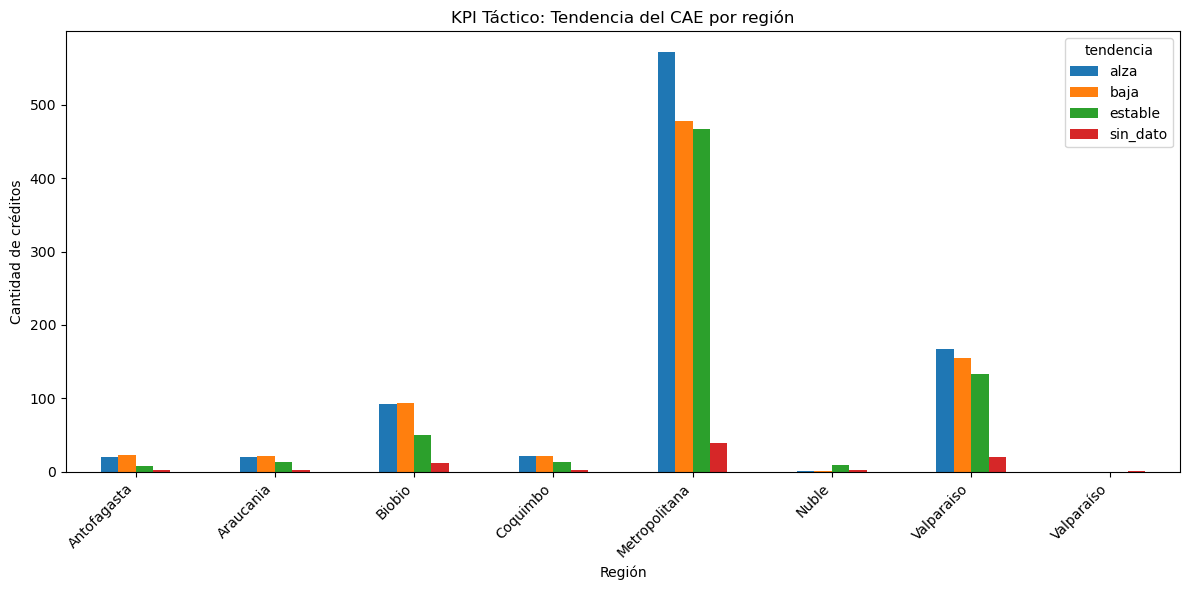

In [19]:
# Convertir KPI táctico a Pandas para graficar
kpi_tactico_pd = kpi_tactico.toPandas()

# Crear tabla dinámica para graficar tendencias por región
tabla_tendencias = kpi_tactico_pd.pivot_table(
    index="region",
    columns="tendencia",
    values="Cantidad_creditos",
    aggfunc="sum",
    fill_value=0
)

tabla_tendencias.plot(kind="bar", figsize=(12, 6))

plt.xlabel("Región")
plt.ylabel("Cantidad de créditos")
plt.title("KPI Táctico: Tendencia del CAE por región")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Este gráfico permite identificar en qué regiones el CAE tiende a subir, bajar o mantenerse estable, apoyando decisiones tácticas de análisis regional.

In [16]:
kpi_operacional = df_historico.withColumn(
    "alerta_cae",
    F.when(F.col("desviacion_vs_banco") > 0, 1).otherwise(0)
).groupBy("banco").agg(
    F.sum("alerta_cae").alias("Creditos_sobre_promedio_banco"),
    F.count("*").alias("Total_creditos"),
    F.round((F.sum("alerta_cae") / F.count("*")) * 100, 2).alias("Porcentaje_alerta")
).orderBy(F.desc("Porcentaje_alerta"))

print("KPI Operacional: Créditos con CAE sobre el promedio del banco")
kpi_operacional.show(truncate=False)

KPI Operacional: Créditos con CAE sobre el promedio del banco
+--------------+-----------------------------+--------------+-----------------+
|banco         |Creditos_sobre_promedio_banco|Total_creditos|Porcentaje_alerta|
+--------------+-----------------------------+--------------+-----------------+
|Santander     |344                          |599           |57.43            |
|BancoEstado   |343                          |600           |57.17            |
|referencia_cmf|549                          |1086          |50.55            |
|BCI           |90                           |184           |48.91            |
+--------------+-----------------------------+--------------+-----------------+



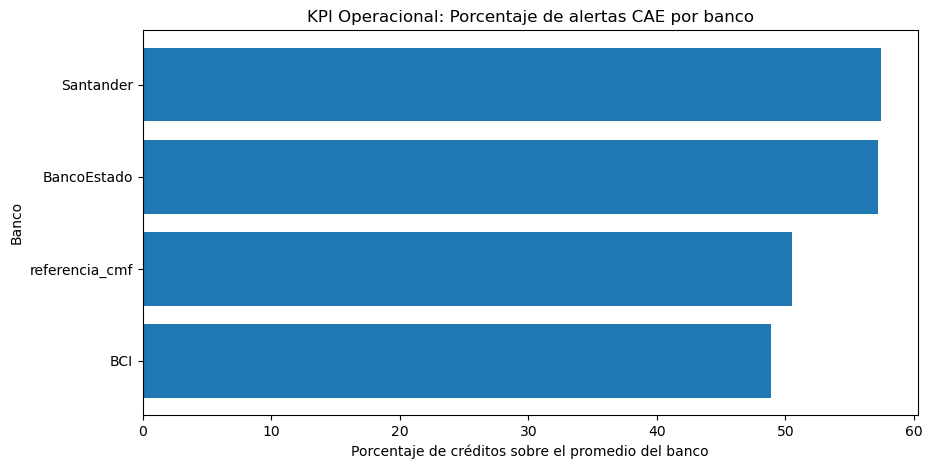

In [20]:
# Convertir KPI operacional a Pandas para graficar
kpi_operacional_pd = kpi_operacional.toPandas()

plt.figure(figsize=(10, 5))
plt.barh(
    kpi_operacional_pd["banco"],
    kpi_operacional_pd["Porcentaje_alerta"]
)

plt.xlabel("Porcentaje de créditos sobre el promedio del banco")
plt.ylabel("Banco")
plt.title("KPI Operacional: Porcentaje de alertas CAE por banco")
plt.gca().invert_yaxis()
plt.show()

Este gráfico permite detectar bancos con mayor porcentaje de créditos sobre su propio promedio de CAE, funcionando como una alerta operacional.

## Cierre Semana 14: Storytelling con datos

A partir del análisis realizado, los datos de créditos hipotecarios permiten construir indicadores útiles para distintos niveles de decisión.

A nivel estratégico, el CAE promedio por banco permite comparar qué instituciones presentan mayores costos financieros. Esto ayuda a observar el comportamiento general del mercado hipotecario y apoyar decisiones de análisis financiero.

A nivel táctico, la tendencia del CAE por región permite identificar zonas donde los créditos tienden a subir, bajar o mantenerse estables. Esto permite enfocar el análisis en regiones con mayor variación.

A nivel operacional, el indicador de créditos con CAE sobre el promedio del banco permite detectar casos que se alejan del comportamiento esperado. Esto puede funcionar como una alerta para revisar créditos específicos.

En conclusión, el storytelling permite transformar datos técnicos en información clara para la toma de decisiones. En este proyecto, los datos ayudan a entender mejor el comportamiento del CAE en créditos hipotecarios y apoyan decisiones estratégicas, tácticas y operacionales.
